# Proyecto de Regresión Lineal - Coste del Seguro Médico

## Objetivo

En este proyecto construiremos un modelo de regresión lineal capaz de predecir el coste del seguro médico (`charges`) de un cliente a partir de sus características personales.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Cargamos el dataset
df = pd.read_csv("../data/raw/medical_insurance_cost.csv")

In [3]:
df.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


##El dataset contiene 1338 registros y 7 columnas.
No existen valores nulos, por lo que inicialmente no será necesario tratar datos faltantes.
Hay 4 variables numéricas (age, bmi, children y charges) y 3 variables categóricas (sex, smoker y region).
La variable objetivo será charges, que representa el coste del seguro médico.
Antes de entrenar el modelo será necesario transformar las variables categóricas en variables numéricas para que la regresión lineal pueda utilizarlas.

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

El dataset contiene 7 variables. Cuatro son numéricas (age, children, bmi y charges) y tres son categóricas (sex, smoker y region). Las variables categóricas deberán transformarse a formato numérico antes de entrenar un modelo de Machine Learning.

In [11]:
df["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [12]:
df["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [13]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

## Comienza el eda


## Variables categoricas


In [14]:
# Función para analizar variables categóricas
def analizar_categorica(df, columna):

    conteo = df[columna].value_counts()

    print(conteo)

    conteo.plot(kind="bar")

    plt.title(f"Distribución de la variable '{columna}'")
    plt.xlabel(columna)
    plt.ylabel("Número de clientes")

    plt.show()

sex
male      675
female    662
Name: count, dtype: int64


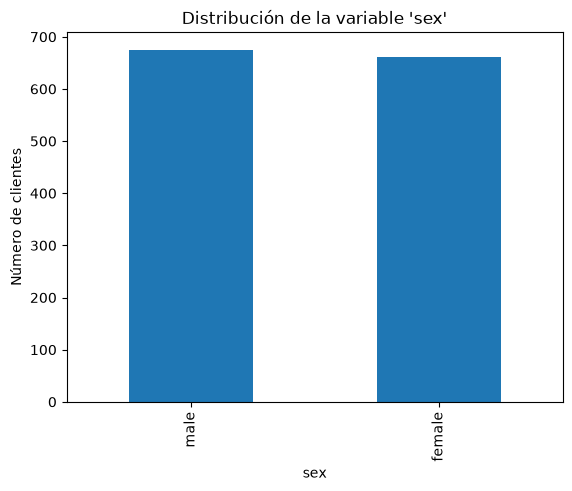

In [15]:
analizar_categorica(df, "sex")

smoker
no     1063
yes     274
Name: count, dtype: int64


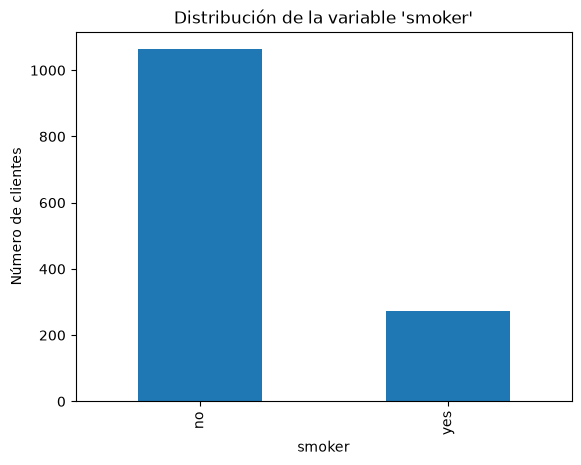

In [16]:
analizar_categorica(df, "smoker")


region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


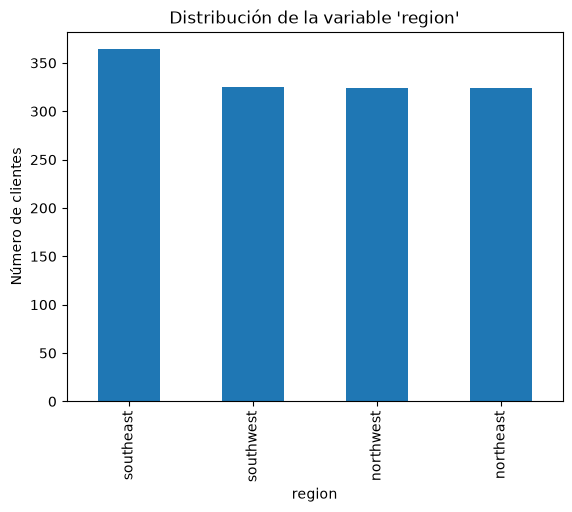

In [17]:
analizar_categorica(df, "region")

## variables numerica

In [18]:
# Función para analizar variables numéricas
def analizar_numerica(df, columna):

    fig, ax = plt.subplots(1, 2, figsize=(14,4))

    # Histograma
    sns.histplot(df[columna], kde=True, ax=ax[0])
    ax[0].set_title(f"Distribución de '{columna}'")

    # Boxplot
    sns.boxplot(x=df[columna], ax=ax[1])
    ax[1].set_title(f"Boxplot de '{columna}'")

    plt.tight_layout()
    plt.show()

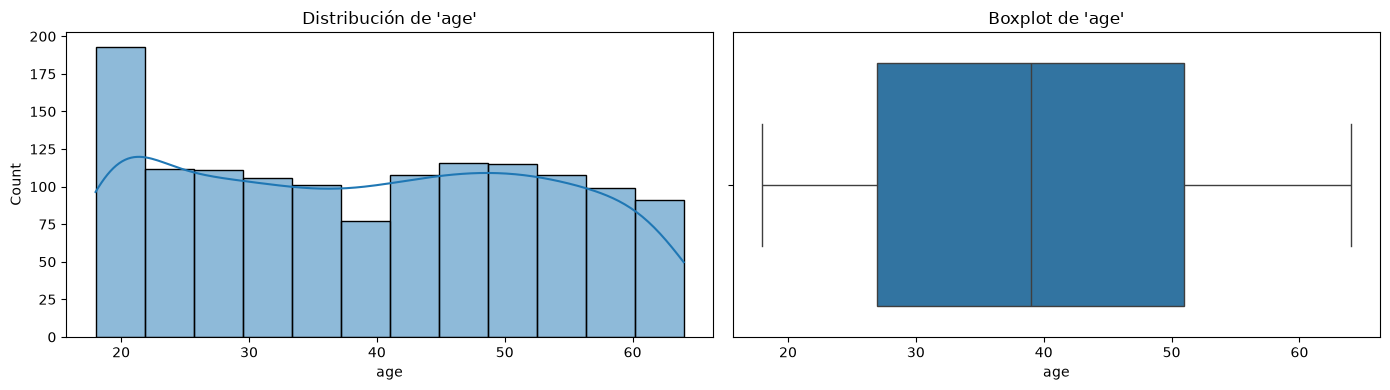

In [19]:
analizar_numerica(df, "age")

La variable age presenta una distribución bastante equilibrada entre los 18 y los 64 años, aunque se observa un ligero pico alrededor de los 20 años. En el boxplot no se identifican valores atípicos, por lo que no parece haber edades fuera del rango esperado. Como hipótesis de negocio, es razonable pensar que la edad pueda influir en el coste del seguro médico, aunque esta relación deberá comprobarse más adelante mediante un análisis bivariante.

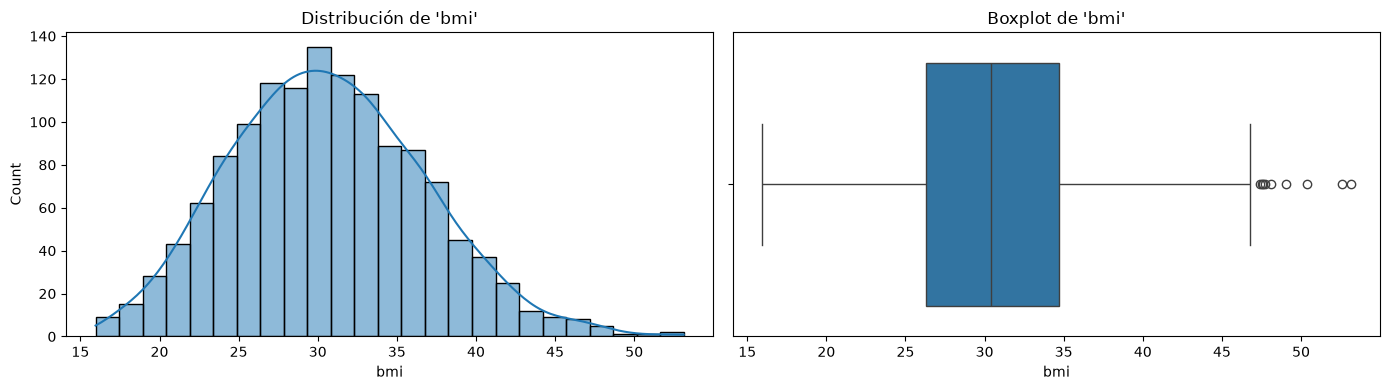

In [20]:
analizar_numerica(df, "bmi")

La variable bmi presenta una distribución aproximadamente normal con un ligero sesgo hacia la derecha. El boxplot muestra la presencia de varios valores atípicos, correspondientes a personas con un índice de masa corporal superior al habitual. Como hipótesis de negocio, es posible que el BMI influya en el coste del seguro médico, aunque esta relación deberá confirmarse en el análisis bivariante.

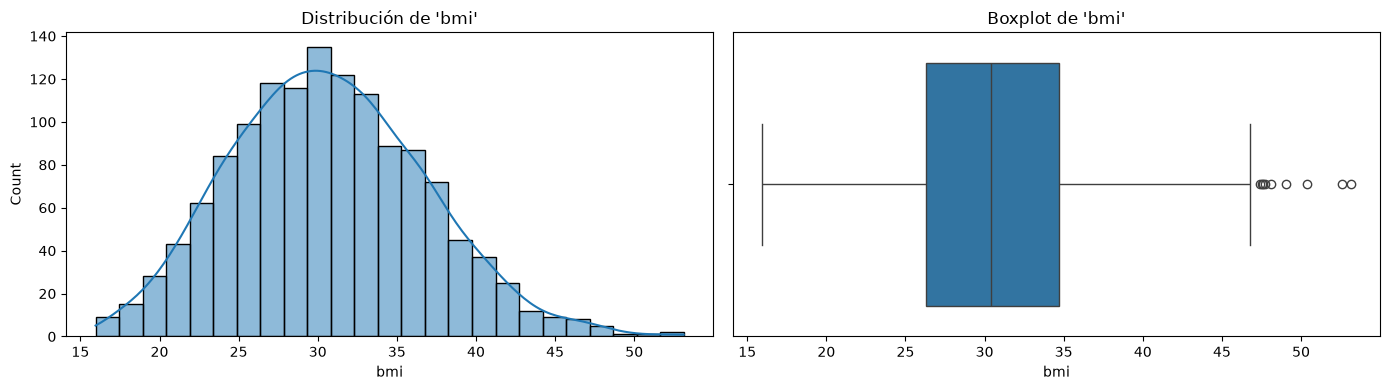

In [21]:
analizar_numerica(df, "bmi")

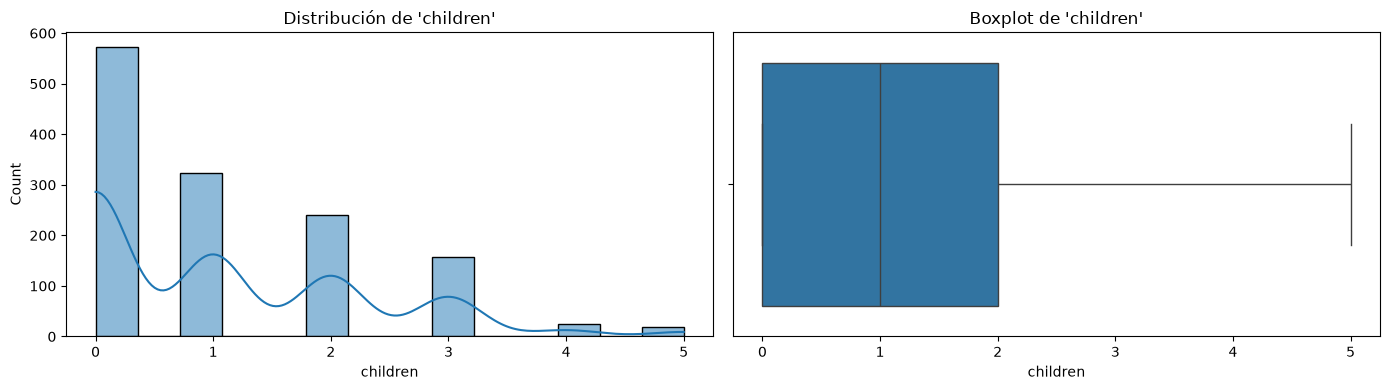

In [22]:
analizar_numerica(df, "children")

La variable children presenta una distribución claramente asimétrica hacia la derecha. La mayoría de los clientes no tienen hijos, y a medida que aumenta el número de hijos, disminuye la frecuencia de clientes en el dataset.No se observan valores atipicos

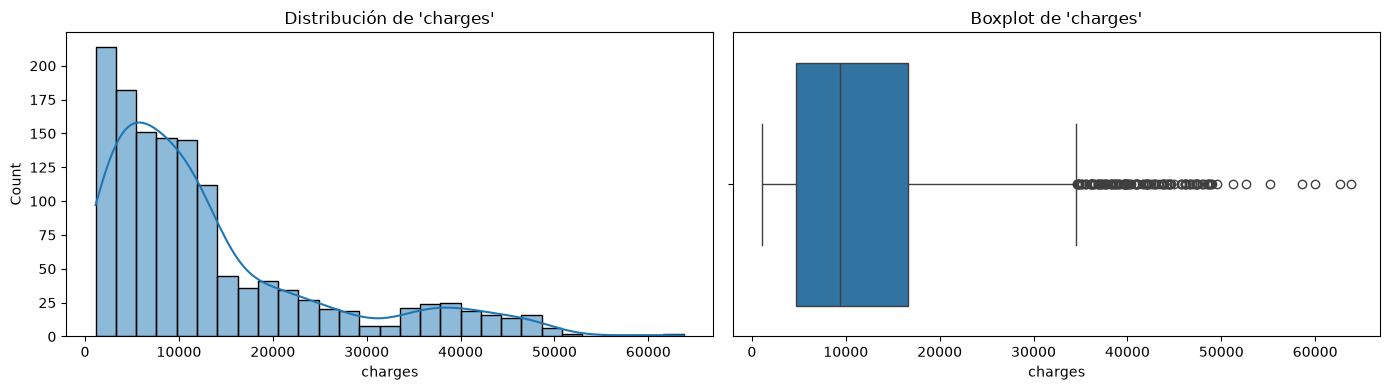

In [23]:
analizar_numerica(df, "charges")

La variable charges presenta una distribución claramente asimétrica con un fuerte sesgo hacia la derecha. La mayoría de los clientes tienen costes relativamente bajos, mientras que existe un grupo reducido con costes muy elevados. Además, el boxplot muestra la presencia de numerosos valores atípicos (outliers), correspondientes a clientes con gastos significativamente superiores al resto.

## Analisis bivariante usando la variable "charges" con las demas( es la buscada)


In [24]:
# Función para analizar la relación entre dos variables numéricas
def analizar_relacion_numerica(df, x, y):

    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )

    plt.title(f"Relación entre {x} y {y}")
    plt.xlabel(x)
    plt.ylabel(y)

    plt.show()

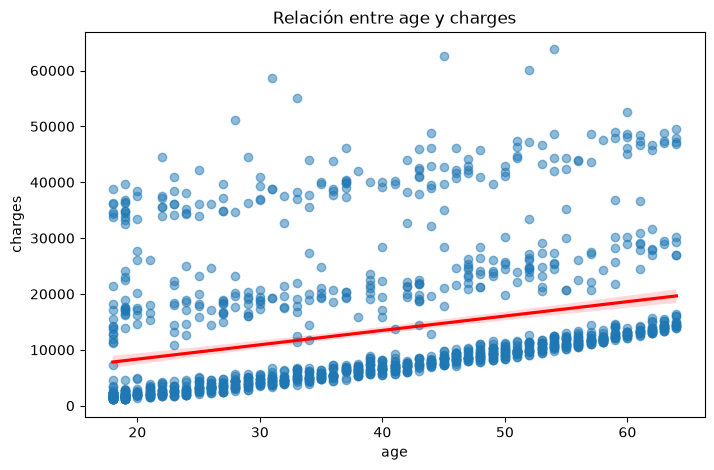

In [26]:
analizar_relacion_numerica(df, "age", "charges")

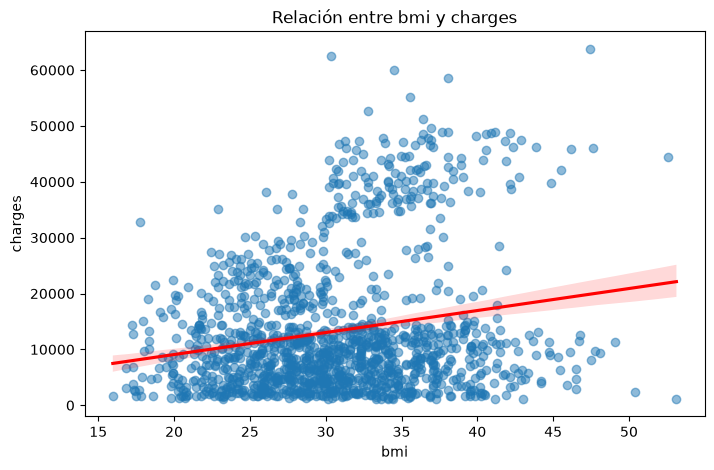

In [27]:
analizar_relacion_numerica(df, "bmi", "charges")

<Axes: xlabel='children', ylabel='charges'>

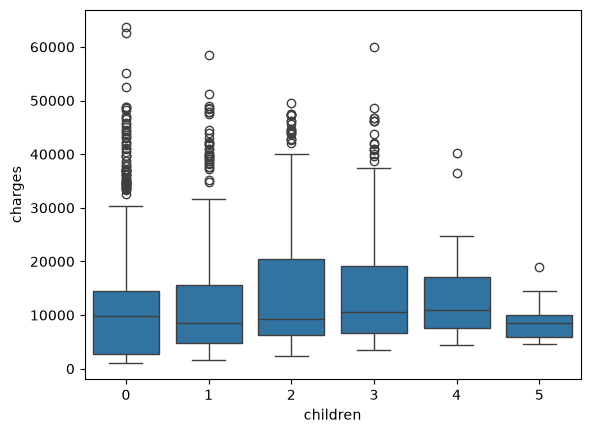

In [28]:
sns.boxplot(data=df, x="children", y="charges")

A simple vista, no se observan diferencias muy marcadas según el número de hijos. Esto sugiere que children podría tener una influencia menor sobre el coste del seguro que otras variables analizadas hasta el momento, aunque esta hipótesis deberá confirmarse con análisis posteriores.

<Axes: xlabel='smoker', ylabel='charges'>

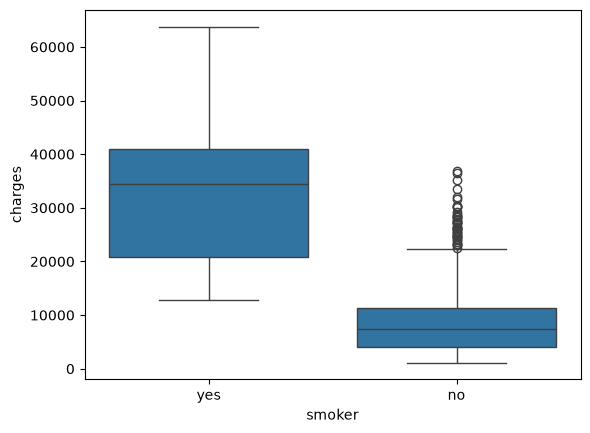

In [30]:
sns.boxplot(data=df, x="smoker", y="charges")

La variable smoker muestra una diferencia muy marcada en los costes del seguro médico. Los clientes fumadores presentan una mediana de charges muy superior a la de los no fumadores. Mientras que en los no fumadores la mediana se sitúa por debajo de los 10.000 dólares anuales, en los fumadores supera los 30.000 dólares. Además, ambos grupos presentan valores atípicos, aunque estos son mucho más elevados en el grupo de fumadores.

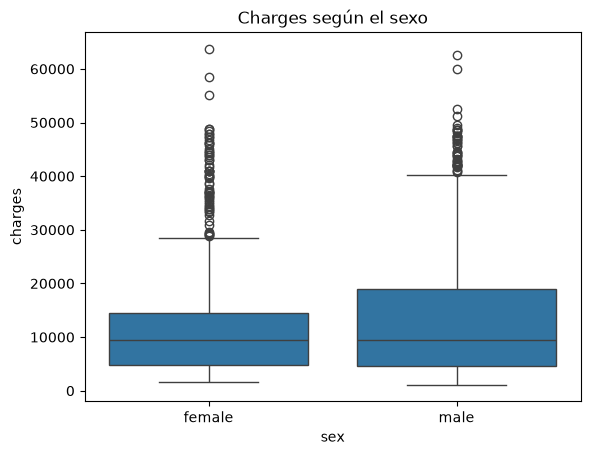

In [31]:
sns.boxplot(data=df, x="sex", y="charges")
plt.title("Charges según el sexo")
plt.show()

La variable sex no muestra diferencias importantes en los costes del seguro médico. La mediana de hombres y mujeres es muy similar, lo que sugiere que el sexo, por sí solo, no parece ser un factor determinante para explicar charges. Se observa una mayor dispersión en el grupo de hombres, aunque esta diferencia no parece suficiente para considerar que el sexo tenga una influencia comparable a la observada en variables como smoker o bmi.

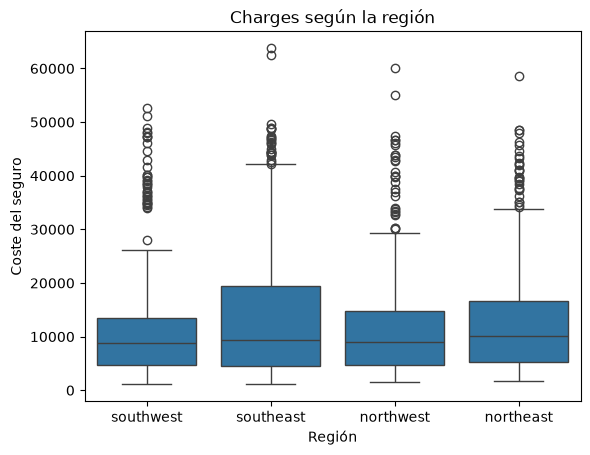

In [33]:
sns.boxplot(data=df, x="region", y="charges")
plt.title("Charges según la región")
plt.xlabel("Región")
plt.ylabel("Coste del seguro")
plt.show()

La variable region no muestra diferencias importantes en la mediana de los costes del seguro, ya que las cuatro regiones presentan valores muy similares. Aunque existen diferencias en la dispersión y aparecen valores atípicos en todas ellas, visualmente no parece que la región sea un factor determinante para explicar charges, especialmente si se compara con el efecto observado en la variable smoker.

In [36]:
pd.factorize(df["sex"])

(array([0, 1, 1, ..., 0, 0, 0], shape=(1337,)),
 Index(['female', 'male'], dtype='str'))

In [37]:
sex_codes, sex_categories = pd.factorize(df["sex"])

In [38]:
sex_codes

array([0, 1, 1, ..., 0, 0, 0], shape=(1337,))

In [39]:
sex_categories

Index(['female', 'male'], dtype='str')

In [40]:
pd.factorize(df["smoker"])

(array([0, 1, 1, ..., 1, 1, 0], shape=(1337,)),
 Index(['yes', 'no'], dtype='str'))

In [44]:
smoker_codes, smoker_categories = pd.factorize(df["smoker"])

In [42]:
pd.factorize(df["region"])

(array([0, 1, 1, ..., 1, 0, 2], shape=(1337,)),
 Index(['southwest', 'southeast', 'northwest', 'northeast'], dtype='str'))

In [45]:
region_codes, region_categories = pd.factorize(df["region"])

In [46]:
df["sex"] = sex_codes
df["smoker"] = smoker_codes
df["region"] = region_codes